In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
#from matplotlib.ticker import MaxNLocator
from scipy.stats import mannwhitneyu

# Centrosome analysis

Channel 1 (RED) - pericentrin
Channel 2 (GREEN) - gamma-tubulin

## Parameters

In [2]:
DIR = "/mnt/c/users/helen/Desktop/test"
THRESHOLD = 3 # % cells with >=3 objects
PARAMETER = "centrosomes"
OUTPUT_DIR = "./test"

## Data loading

In [3]:
from utils import load_data, data_subset

In [4]:
df = load_data(DIR)

In [5]:
df.tail()

,,Image,Cell,Channel number,ROI,File,Path
6,2,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,2,0515-1074,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
7,3,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,1,0273-1112,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
8,4,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,1,0276-1105,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
9,5,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2,0264-1113,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...
10,6,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2,0269-1112,results_2_hct116_wt_pcdna_vacio__pcnt-gamma_tu...,/mnt/c/users/helen/Desktop/test/test_results/r...


In [6]:
ch1 = data_subset(df, channel = 1)
ch2 = data_subset(df, channel = 2)

## Data processing

In [7]:
roi_counts = (
    ch2.groupby(["Image", "Cell"])["ROI"]
       .count()
       .reset_index(name="Objects_number")
)

In [8]:
roi_counts

,Image,Cell,Objects_number
0,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,3
1,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,1
2,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2


# TEST

In [9]:
from utils import processing

In [10]:
data = {
    "Image": [
        "2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma_tub-07",
        "2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma_tub-07",
        "2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma_tub-07",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-05",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-01",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-01",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-01",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-02",
        "2_hct116_wt_aph1a_g4__pcnt-gamma_tub-02",
    ],

    "Cell": [
        1, 2, 3,
        1, 2, 3,
        1, 2, 3, 4,
        1, 2, 3,
        1, 2
    ],

    "Objects_number": [
        3, 2, 4,
        1, 2, 2,
        2, 3, 1, 2,
        4, 3, 5,
        2, 4
    ]
}

df = pd.DataFrame(data)

In [11]:
# Add sample column manually
df['Sample'] = df['Image'].apply(lambda x: 'sample1' if 'pcdna_vacio' in x else 'sample2')

In [12]:
df.head()

,Image,Cell,Objects_number,Sample
0,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,1,3,sample1
1,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,2,2,sample1
2,2_hct116_wt_pcdna_vacio_+_aph1a_g4__pcnt-gamma...,3,4,sample1
3,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,1,1,sample1
4,2_hct116_wt_pcdna_vacio__pcnt-gamma_tub-04,2,2,sample1


In [13]:
results = processing(df = df, threshold = THRESHOLD)

In [ ]:
results

## Graphs

In [14]:
from utils import barplot_normal

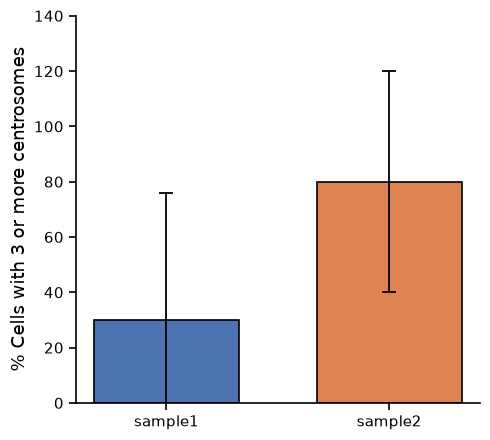

In [15]:
barplot_normal(
            df=results,
            output_dir=OUTPUT_DIR
               )